
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

## <span style="color:green; font-size: 30px">Solución</span>

**Ecuación de Schrödinger**

$$-\frac{\hbar^2}{2m} \nabla^2 \psi(\vec{r}) + U(\vec{r})\psi(\vec{r}) = E\psi(\vec{r})$$

**Unidades de Hartree:** $m_e = 1, \quad e = 1, \quad \hbar = 1, \quad 4\pi\varepsilon_0 = 1$

Si $\psi(\vec{r})$ depende únicamente de $r = |\vec{r}| = \sqrt{x^2+y^2+z^2}$, **(no tiene depedencia angular l=0, orbitales s)**

$$U(r) = -\frac{e^2}{4\pi\varepsilon_0 r} \quad \text{por tanto} \quad \nabla^2 \psi(r) = \frac{1}{r^2} \frac{d}{dr}\left( r^2 \frac{d\psi(r)}{dr} \right)$$

Sustituyendo:

$$-\frac{\hbar^2}{2m} \frac{1}{r^2} \frac{d}{dr}\left( r^2 \frac{d\psi(r)}{dr} \right) - \frac{e^2}{4\pi\varepsilon_0 r} \psi(r) = E\psi(r) \quad \text{--- (1)}$$

---

Si $u(r) = r \psi(r) \implies \psi(r) = \frac{u(r)}{r}$:

$$\frac{d\psi}{dr} = \frac{d}{dr}\left(\frac{u}{r}\right) = \frac{u'r - r'u}{r^2} = \frac{u'}{r} - \frac{u}{r^2} \implies r^2 \frac{d\psi}{dr} = r u' - u$$

$$\implies \frac{d}{dr} \left[ r^2 \frac{d\psi}{dr} \right] = \frac{d}{dr}(r u' - u) = u' + r u'' - u' = r \frac{d^2 u}{dr^2} \implies \frac{1}{r^2} \frac{d}{dr}\left[ r^2 \frac{d\psi}{dr} \right] = \frac{1}{r} \frac{d^2 u}{dr^2} \quad \text{--- (2)}$$

Sustituyendo (2) en (1):

$$-\frac{\hbar^2}{2m r} \frac{d^2 u(r)}{dr^2} - \frac{e^2}{4\pi\varepsilon_0 r} \left( \frac{u(r)}{r} \right) = E \left( \frac{u(r)}{r} \right) \implies -\frac{\hbar^2}{2m} \frac{d^2 u(r)}{dr^2} - \frac{e^2}{4\pi\varepsilon_0 r} u(r) = E u(r)$$

Adoptando **unidades atómicas**:

$$-\frac{1}{2}\frac{d^2 u(r)}{dr^2} - \frac{1}{r}u(r) = E u(r)$$




Realizando la discretización del espacio

$$\Delta r = \frac{r_{\text{max}} - r_{\text{min}}}{N + 1} \implies r_i = r_{\text{min}} + i \Delta r$$

Aproximando la segunda derivada mediante diferencias finitas centradas:

$$\implies -\frac{1}{2} \left( \frac{u_{i+1} + u_{i-1} - 2u_i}{\Delta r^2} \right) - \frac{1}{r_i} u_i = E u_i$$

Reagrupando los términos para cada $u$:

$$\implies \left( -\frac{1}{2 \Delta r^2} \right) u_{i-1} + \left( -\frac{1}{2 \Delta r^2} \right) u_{i+1} + \left( \frac{1}{\Delta r^2} - \frac{1}{r_i} \right) u_i = E u_i$$

Condiciones de frontera:
$$u_0 = u_{N+1} = 0$$

Para $i = 1$:
$$\left( \frac{1}{\Delta r^2} - \frac{1}{r_1} \right) u_1 + \left( -\frac{1}{2\Delta r^2} \right) u_2 = E u_1$$

Para $i = 2$:
$$\left( -\frac{1}{2\Delta r^2} \right) u_1 + \left( \frac{1}{\Delta r^2} - \frac{1}{r_2} \right) u_2 + \left( -\frac{1}{2\Delta r^2} \right) u_3 = E u_2$$

$$\vdots$$

Para $i = N$:
$$\left( -\frac{1}{2\Delta r^2} \right) u_{N-1} + \left( \frac{1}{\Delta r^2} - \frac{1}{r_N} \right) u_N = E u_N$$

Por tanto $\mathbf{Au} = E\mathbf{u}$, donde $\mathbf{A}$ es:

$$\mathbf{A} = \begin{pmatrix}
\left( \frac{1}{\Delta r^2} - \frac{1}{r_1} \right) & -\frac{1}{2\Delta r^2} & 0 & \dots & 0 & 0 \\
-\frac{1}{2\Delta r^2} & \left( \frac{1}{\Delta r^2} - \frac{1}{r_2} \right) & -\frac{1}{2\Delta r^2} & \dots & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
0 & 0 & 0 & \dots & -\frac{1}{2\Delta r^2} & \left( \frac{1}{\Delta r^2} - \frac{1}{r_N} \right)
\end{pmatrix}$$

y $\mathbf{u}$ es:

$$\mathbf{u} = \begin{pmatrix}
u_1 \\
u_2 \\
\vdots \\
u_N
\end{pmatrix}$$


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la
import scipy.special as spe

In [14]:
R = 30
r = 0
# Numero de puntos
N = 1000
delta_r = (R-r)/(N+1)

In [15]:
x = np.linspace(delta_r,R-delta_r,N)
A = np.zeros((N,N), float)

In [16]:
for i in range(N):    
    if i == 0:
        A[i,i] = (1/(delta_r**2) - 1/x[i])
        A[i,i+1] = -1/(2*delta_r**2)
    elif i == (N-1):
        A[i,i] = (1/(delta_r**2) - 1/x[i])
        A[i,i-1] = -1/(2*delta_r**2)
    else:
        A[i,i] = (1/(delta_r**2) - 1/x[i])
        A[i,i-1] = -1/(2*delta_r**2)
        A[i,i+1] = -1/(2*delta_r**2)

In [17]:
for i in range(N):
    A[i, i] = (1 / delta_r**2) - (1 / x[i])
    if i > 0:
        A[i, i - 1] = -1 / (2 * delta_r**2)
    if i < N - 1:
        A[i, i + 1] = -1 / (2 * delta_r**2)

In [18]:
energies, wavefunctions = la.eigh(A)
print("Autovalores de energía (en Hartree):")
for n, E in enumerate(energies[:3], start=1):
    print(f"E_{n} calculada = {E:.5f} Ha")

Autovalores de energía (en Hartree):
E_1 calculada = -0.49989 Ha
E_2 calculada = -0.12499 Ha
E_3 calculada = -0.05542 Ha


In [19]:
# Tomar el primer autovector (estado fundamental, n=1)
u_1 = wavefunctions[:, 0]

# Convertir u(r) a R(r) dividiendo por r
R_1 = u_1 / x

# Normalizar la función de onda radial en la malla
norma = np.sqrt(np.sum(u_1**2) * delta_r)
u_1_norm = u_1 / norma

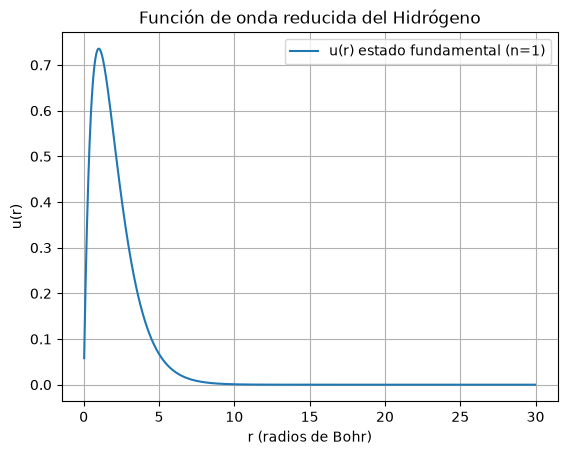

In [20]:
plt.plot(x, u_1_norm, label="u(r) estado fundamental (n=1)")
plt.xlabel("r (radios de Bohr)")
plt.ylabel("u(r)")
plt.title("Función de onda reducida del Hidrógeno")
plt.grid(True)
plt.legend()
plt.show()

<span style="color:#7EED6D; font-size: 25px">Codigo Extraido de la Sesion FDM Schrodinger</span>

In [21]:
def psi_R(r,n=1,l=0):
    coeff = np.sqrt((2.0/n)**3*spe.factorial(n-l-1) /(2.0*n*spe.factorial(n+l)))
    laguerre = spe.assoc_laguerre(2.0*r/n,n-l-1,2*l+1)
    #a0 = 1
    rho = 2.0*r/n
    return coeff*np.exp(-r/n)*rho**l*laguerre

<span style="color:#7EED6D; font-size: 25px">Comparacion de Solución Analitica vs FDM </span>

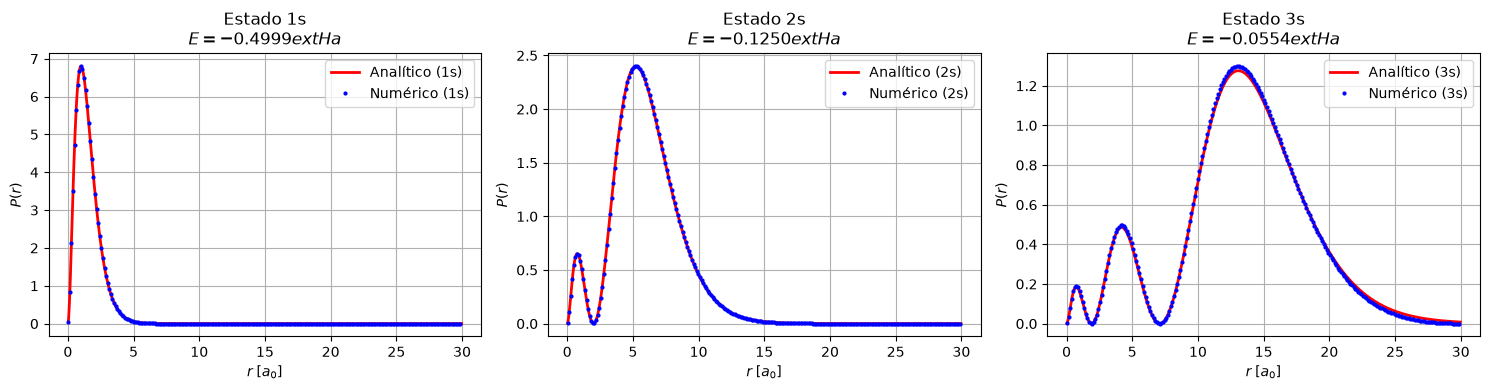

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
estados = [(1, "1s"), (2, "2s"), (3, "3s")]

for idx, (n_val, label) in enumerate(estados):
    ax = axes[idx]

    # Densidad analítica
    R_exacto = psi_R(x, n=n_val, l=0)
    P_exacto = 4 * np.pi * (x**2) * (R_exacto**2)

    # Densidad numérica (u_i / sqrt(delta_r)) normaliza u(r)
    u_num = wavefunctions[:, idx] / np.sqrt(delta_r)
    P_num = 4 * np.pi * (u_num**2)  # x**2 ya esta incluido dentro u_num

    ax.plot(x, P_exacto, "r-", lw=2, label=f"Analítico ({label})")
    ax.plot(x, P_num, "bo", lw=2, label=f"Numérico ({label})", markevery=4,markersize=2)
    ax.set_title(f"Estado {label}\n$E = {energies[idx]:.4f}\text{{ Ha}}$")
    ax.set_xlabel(r"$r \; [a_0]$")
    ax.set_ylabel(r"$P(r)$")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Proponiendo separación de variables para orbitales con momento angular $l > 0$ ($\psi(\vec{r}) = R(r)Y_{lm}(\theta, \phi)$):

$$U(r) = -\frac{e^2}{4\pi\varepsilon_0 r} \quad \text{por tanto} \quad \nabla^2 \psi = Y_{lm} \frac{1}{r^2}\frac{d}{dr}\left(r^2 \frac{dR(r)}{dr}\right) - \frac{l(l+1)}{r^2} R(r) Y_{lm}$$

Sustituyendo:

$$-\frac{\hbar^2}{2m} \frac{1}{r^2} \frac{d}{dr}\left(r^2 \frac{dR(r)}{dr}\right) + \frac{\hbar^2 l(l+1)}{2m r^2} R(r) - \frac{e^2}{4\pi\varepsilon_0 r} R(r) = E R(r) \quad \text{--- (1)}$$

---

Si $u(r) = r R(r) \implies R(r) = \frac{u(r)}{r}$:

$$\frac{dR}{dr} = \frac{d}{dr}\left(\frac{u}{r}\right) = \frac{u' r - r' u}{r^2} = \frac{u'}{r} - \frac{u}{r^2} \implies r^2 \frac{dR}{dr} = r u' - u$$

$$\implies \frac{d}{dr}\left[r^2 \frac{dR}{dr}\right] = \frac{d}{dr}(r u' - u) = u' + r u'' - u' = r \frac{d^2 u}{dr^2} \implies \frac{1}{r^2} \frac{d}{dr}\left[r^2 \frac{dR}{dr}\right] = \frac{1}{r} \frac{d^2 u}{dr^2} \quad \text{--- (2)}$$

Sustituyendo (2) en (1):

$$-\frac{\hbar^2}{2m r}\frac{d^2 u(r)}{dr^2} + \frac{\hbar^2 l(l+1)}{2m r^2}\left(\frac{u(r)}{r}\right) - \frac{e^2}{4\pi\varepsilon_0 r}\left(\frac{u(r)}{r}\right) = E\left(\frac{u(r)}{r}\right)$$

$$\implies -\frac{\hbar^2}{2m}\frac{d^2 u(r)}{dr^2} + \frac{\hbar^2 l(l+1)}{2m r^2} u(r) - \frac{e^2}{4\pi\varepsilon_0 r} u(r) = E u(r)$$

Adoptando **unidades atómicas**:

$$-\frac{1}{2}\frac{d^2 u(r)}{dr^2} + \left(-\frac{1}{r} + \frac{l(l+1)}{2r^2}\right) u(r) = E u(r)$$

Realizando la discretización del espacio:

$$\Delta r = \frac{r_{\text{max}} - r_{\text{min}}}{N + 1} \implies r_i = r_{\text{min}} + i\Delta r$$

Aproximando la segunda derivada mediante diferencias finitas centradas e incluyendo el término centrífugo ($l > 0$):

$$\implies -\frac{1}{2} \left( \frac{u_{i+1} + u_{i-1} - 2u_i}{\Delta r^2} \right) - \frac{1}{r_i} u_i + \frac{l(l+1)}{2r_i^2} u_i = E u_i$$

Reagrupando los términos para cada $u$:

$$\implies \left( -\frac{1}{2\Delta r^2} \right) u_{i-1} + \left( -\frac{1}{2\Delta r^2} \right) u_{i+1} + \left( \frac{1}{\Delta r^2} - \frac{1}{r_i} + \frac{l(l+1)}{2r_i^2} \right) u_i = E u_i$$

Condiciones de frontera:

$$u_0 = u_{N+1} = 0$$

Para $i = 1$:

$$\left( \frac{1}{\Delta r^2} - \frac{1}{r_1} + \frac{l(l+1)}{2r_1^2} \right) u_1 + \left( -\frac{1}{2\Delta r^2} \right) u_2 = E u_1$$

Para $i = 2$:

$$\left( -\frac{1}{2\Delta r^2} \right) u_1 + \left( \frac{1}{\Delta r^2} - \frac{1}{r_2} + \frac{l(l+1)}{2r_2^2} \right) u_2 + \left( -\frac{1}{2\Delta r^2} \right) u_3 = E u_2$$

$$\vdots$$

Para $i = N$:

$$\left( -\frac{1}{2\Delta r^2} \right) u_{N-1} + \left( \frac{1}{\Delta r^2} - \frac{1}{r_N} + \frac{l(l+1)}{2r_N^2} \right) u_N = E u_N$$

Por tanto $\mathbf{A} \mathbf{u} = E \mathbf{u}$, donde $\mathbf{A}$ es:

$$\mathbf{A} = \begin{pmatrix} 
\left(\frac{1}{\Delta r^2} - \frac{1}{r_1} + \frac{l(l+1)}{2r_1^2}\right) & -\frac{1}{2\Delta r^2} & 0 & \dots & 0 & 0 \\ 
-\frac{1}{2\Delta r^2} & \left(\frac{1}{\Delta r^2} - \frac{1}{r_2} + \frac{l(l+1)}{2r_2^2}\right) & -\frac{1}{2\Delta r^2} & \dots & 0 & 0 \\ 
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\ 
0 & 0 & 0 & \dots & -\frac{1}{2\Delta r^2} & \left(\frac{1}{\Delta r^2} - \frac{1}{r_N} + \frac{l(l+1)}{2r_N^2}\right) 
\end{pmatrix}$$

y $\mathbf{u}$ es:

$$\mathbf{u} = \begin{pmatrix} u_1 \\ u_2 \\ \vdots \\ u_N \end{pmatrix}$$

In [ ]:
R = 50
r = 0
l = 1  # Estados p
N = 1000
delta_r = (R - r) / (N + 1)

x = np.linspace(delta_r, R - delta_r, N)
A = np.zeros((N, N), float)

In [47]:
for i in range(N):
    A[i, i] = ((1 / delta_r**2) - (1 / x[i]) + (l * (l + 1)) / (2 * (x[i] ** 2)))
    if i > 0:
        A[i, i - 1] = -1 / (2 * delta_r**2)
    if i < N - 1:
        A[i, i + 1] = -1 / (2 * delta_r**2)

In [48]:
energies, wavefunctions = la.eigh(A)

print(f"Autovalores de energía para l = {l} (en Hartree):")
for n, E in enumerate(energies[:3], start=l + 1):
    print(f"E_{n} calculada = {E:.5f} Ha")

Autovalores de energía para l = 1 (en Hartree):
E_2 calculada = -0.12501 Ha
E_3 calculada = -0.05556 Ha
E_4 calculada = -0.03122 Ha


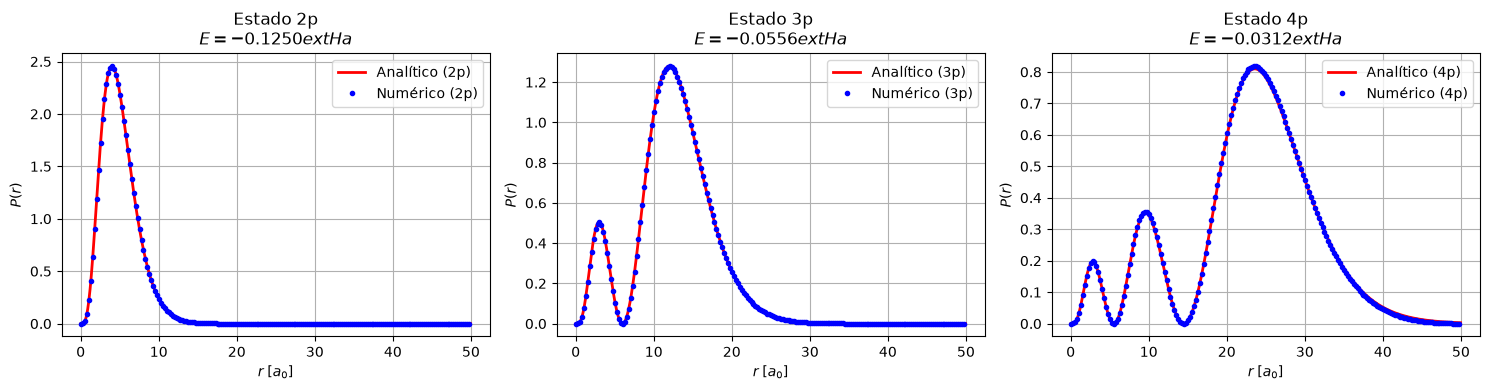

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
estados = [(2, "2p"), (3, "3p"), (4, "4p")]

for idx, (n_val, label) in enumerate(estados):
    ax = axes[idx]

    # 1. Densidad analítica con l = 1
    R_exacto = psi_R(x, n=n_val, l=1)
    P_exacto = 4 * np.pi * (x**2) * (R_exacto**2)

    # 2. Densidad numérica
    u_num = wavefunctions[:, idx] / np.sqrt(delta_r)
    P_num = 4 * np.pi * (u_num**2)

    ax.plot(x, P_exacto, "r-", lw=2, label=f"Analítico ({label})")
    ax.plot(x, P_num, "bo", markevery=5, markersize=3, label=f"Numérico ({label})")

    ax.set_title(rf"Estado {label}" + f"\n$E = {energies[idx]:.4f}\text{{ Ha}}$")
    ax.set_xlabel(r"$r \; [a_0]$")
    ax.set_ylabel(r"$P(r)$")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()